# https://www.hackerrank.com/challenges/battery

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    'https://s3.amazonaws.com/hr-testcases/399/assets/trainingdata.txt', header=None)

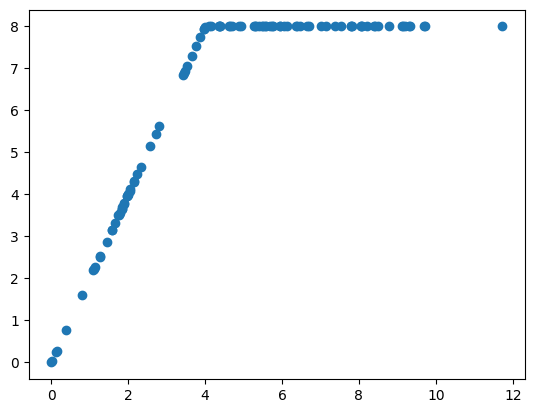

In [3]:
# plot the data column 0 as x and column 1 as y
plt.scatter(df[0], df[1])

In [28]:
df.sort_values(by=0, inplace=True)
df

,0,1
19,0.00,0.00
27,0.02,0.04
76,0.13,0.26
13,0.14,0.28
83,0.39,0.78
...,...,...
67,9.29,8.00
63,9.33,8.00
28,9.69,8.00
36,9.71,8.00


In [24]:

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
# from sklearn.linear_model import Ridge
# from sklearn.linear_model import Lasso



X = df[[0]]
y = df[[1]]

degrees_to_try = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
best_degree = np.inf
best_error = np.inf
for degree in degrees_to_try:
    # X_train, X_test, y_train, y_test = train_test_split(
    #     X, y, test_size=0.2, random_state=42
    # )

    # Pipeline
    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )
    model.fit(X, y)

    pred = model.predict(X)

    mse = mean_squared_error(y, pred)
    print("Error:", round(mse, 3))
    if mse < best_error:
        best_error = mse
        best_degree = degree
print("Best degree:", best_degree)

# # poly = PolynomialFeatures(degree=8)
# # X_poly = poly.fit_transform(X)
# # reg = LinearRegression().fit(X_poly, y)

# # reg.predict(timeCharged)
# # pred = reg.predict(np.array([[timeCharged]]))
# # pred = reg.predict(X_poly)
# # versus the real versus predicted
# plt.scatter(X, y)
# plt.scatter(X, pred, color='red')

# # Metric
# from sklearn.metrics import mean_squared_error
# mse = mean_squared_error(y, pred)
# print("Error:", round(mse, 3))

Error: 1.865
Error: 0.269
Error: 0.131
Error: 0.097
Error: 0.028
Error: 0.026
Error: 0.011
Error: 0.008
Error: 0.006
Error: 0.004
Error: 0.004
Error: 0.004
Error: 0.049
Error: 0.118
Error: 0.502
Error: 0.663
Error: 1.77
Error: 2.164
Error: 2.515
Error: 2.814
Best degree: 12


In [23]:
timeCharged = 0.9



X = df[[0]]
y = df[[1]]

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

model = make_pipeline(
    PolynomialFeatures(degree=12),
    LinearRegression()
)
model.fit(X_train, y_train)

timeCharged = [[timeCharged]]
result = model.predict(timeCharged)
print(round(result[0][0], 2))

1.84
